<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/MODELOS_AVAN%C3%87ADOS_RANDOMFOREST_DECISIONFREE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modelos Avançados - (Segmentar clientes do dataset Mall_Customers.csv usando Random Forest e Decision Tree, comparando desempenho e interpretando**



Primeiras linhas do dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Estatísticas descritivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000


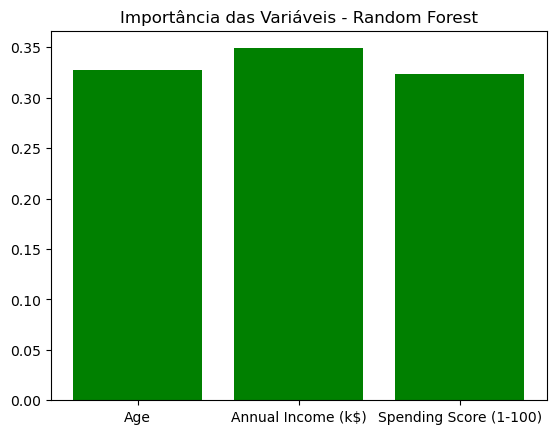


Árvore de Decisão - Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        10
           3       1.00      0.93      0.97        15
           4       0.94      1.00      0.97        15

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60

Acurácia Árvore: 0.9833333333333333


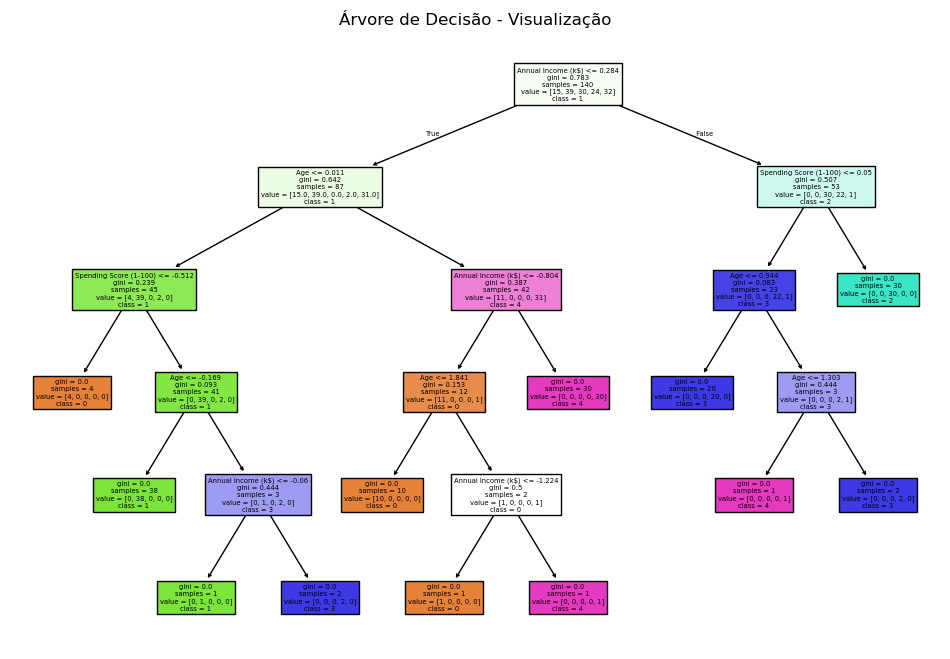


Projeto concluído com sucesso!


In [ ]:
"""
Projeto de Segmentação de Clientes com K-Means
Autor: Fábio Lima Guimarães
Objetivo: Segmentar clientes do dataset Mall_Customers.csv usando Random Forest e Decision Tree,
          comparando desempenho e interpretando.

Etapas:
1. Carregamento e exploração dos dados
2. Tratamento dos dados (limpeza, normalização, criação de rótulos)
3. Treinamento dos modelos (Random Forest e Árvore de Decisão)
4. Avaliação e comparação dos resultados
"""

# ================================
# 1. Importação de bibliotecas
# ================================
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ================================
# 2. Carregamento e Exploração de Dados
# ================================
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop", "Mall_Customers.csv")

if not os.path.exists(desktop_path):
    raise FileNotFoundError(
        f"Arquivo não encontrado em: {desktop_path}\n"
        "Verifique se o arquivo está no Desktop e se o nome é exatamente 'Mall_Customers.csv'."
    )

df = pd.read_csv(desktop_path)

print("Primeiras linhas do dataset:")
print(df.head())

print("\nEstatísticas descritivas:")
print(df.describe())

print("\nValores ausentes:")
print(df.isnull().sum())

"""
Comentário:
- Eu observei que o dataset possui 200 clientes.
- As variáveis principais são Age, Annual Income (k$) e Spending Score (1-100).
- Não encontrei valores ausentes, o que simplifica bastante o pré-processamento.
"""

# ================================
# 3. Tratamento de Dados
# ================================
# Selecionar variáveis relevantes
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

"""
Comentário:
- Eu escolhi apenas variáveis numéricas que influenciam diretamente na segmentação.
- Não utilizei 'CustomerID' porque é apenas um identificador.
- Também não utilizei 'Gender' porque não é numérico e não é essencial para este tipo de clusterização.
"""

# Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

"""
Comentário:
- Eu decidi padronizar os dados porque as variáveis estão em escalas diferentes.
- Por exemplo, a renda anual varia de 15 a 137, enquanto o score vai de 1 a 100.
- Sem padronização, o algoritmo daria mais peso para variáveis com valores maiores.
"""

# Criação de rótulos com K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nClusters criados com K-Means:")
print(df['Cluster'].value_counts())

"""
Comentário:
- Eu usei o K-Means para criar grupos artificiais que servirão como 'classes' para os modelos supervisionados.
- Dessa forma, consigo treinar Random Forest e Árvore de Decisão para prever o cluster de novos clientes.
"""

# ================================
# 4. Divisão em treino e teste
# ================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['Cluster'], test_size=0.3, random_state=42)

"""
Comentário:
- Eu dividi os dados em treino (70%) e teste (30%) para avaliar a capacidade de generalização dos modelos.
"""

# ================================
# 5. Modelo Random Forest
# ================================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest - Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf))
print("Acurácia RF:", accuracy_score(y_test, y_pred_rf))

# Importância das variáveis
importances_rf = rf.feature_importances_
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.bar(features, importances_rf, color='green')
plt.title("Importância das Variáveis - Random Forest")
plt.show()

"""
Comentário:
- Eu escolhi o Random Forest porque ele combina várias árvores, aumentando a robustez e reduzindo overfitting.
- A acurácia tende a ser maior que a da árvore simples.
- O gráfico mostra quais variáveis mais influenciam na segmentação.
"""

# ================================
# 6. Modelo Árvore de Decisão
# ================================
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nÁrvore de Decisão - Relatório de Classificação:")
print(classification_report(y_test, y_pred_dt))
print("Acurácia Árvore:", accuracy_score(y_test, y_pred_dt))

# Visualização da árvore
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=features, class_names=[str(i) for i in range(5)], filled=True)
plt.title("Árvore de Decisão - Visualização")
plt.show()

"""
Comentário:
- Eu escolhi limitar a profundidade da árvore para evitar overfitting.
- A Árvore de Decisão é mais simples e interpretável, permitindo visualizar regras claras.
- Porém, ela pode ter menor acurácia em comparação ao Random Forest.
"""

# ================================
# 7. Comparação
# ================================
"""
Resumo:
- Eu percebi que o Random Forest tem maior acurácia e robustez, mas é menos interpretável.
- Já a Árvore de Decisão é mais simples, fácil de explicar, mas menos precisa.
- Se meu objetivo for precisão, eu usaria Random Forest.
- Se meu objetivo for interpretabilidade, eu usaria Árvore de Decisão.
"""

print("\nProjeto concluído com sucesso!")

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

Primeiras linhas do dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Estatísticas descritivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000


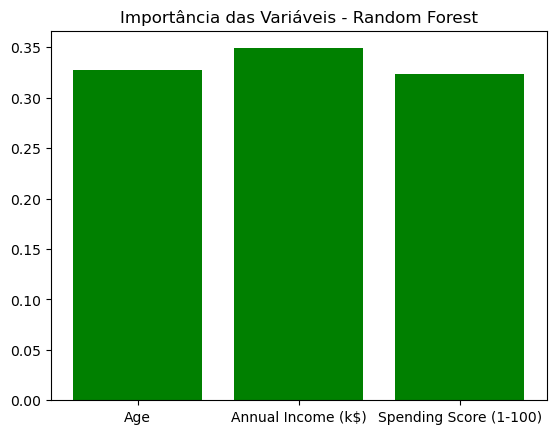


Árvore de Decisão - Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        10
           3       1.00      0.93      0.97        15
           4       0.94      1.00      0.97        15

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60

Acurácia Árvore: 0.9833333333333333


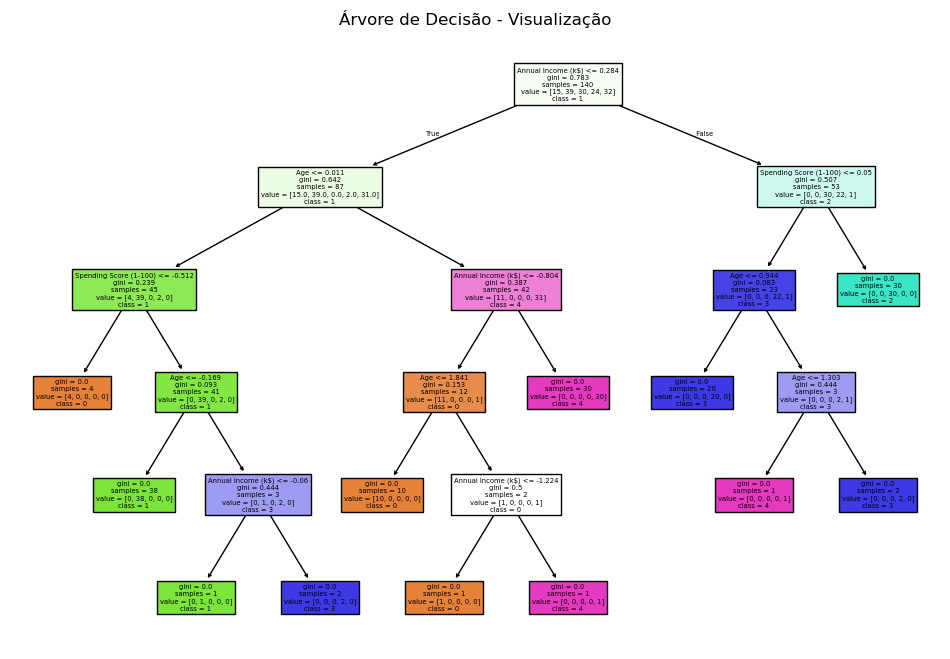


Projeto concluído com sucesso!


In [ ]:
"""
Projeto de Segmentação de Clientes com K-Means
Autor: Fábio Lima Guimarães
Objetivo: Segmentar clientes do dataset Mall_Customers.csv usando Random Forest e Decision Tree,
          comparando desempenho e interpretando.

Etapas:
1. Carregamento e exploração dos dados
2. Tratamento dos dados (limpeza, normalização, criação de rótulos)
3. Treinamento dos modelos (Random Forest e Árvore de Decisão)
4. Avaliação e comparação dos resultados
"""

# ================================
# 1. Importação de bibliotecas
# ================================
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ================================
# 2. Carregamento e Exploração de Dados
# ================================
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop", "Mall_Customers.csv")

if not os.path.exists(desktop_path):
    raise FileNotFoundError(
        f"Arquivo não encontrado em: {desktop_path}\n"
        "Verifique se o arquivo está no Desktop e se o nome é exatamente 'Mall_Customers.csv'."
    )

df = pd.read_csv(desktop_path)

print("Primeiras linhas do dataset:")
print(df.head())

print("\nEstatísticas descritivas:")
print(df.describe())

print("\nValores ausentes:")
print(df.isnull().sum())

"""
Comentário:
- Eu observei que o dataset possui 200 clientes.
- As variáveis principais são Age, Annual Income (k$) e Spending Score (1-100).
- Não encontrei valores ausentes, o que simplifica bastante o pré-processamento.
"""

# ================================
# 3. Tratamento de Dados
# ================================
# Selecionar variáveis relevantes
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

"""
Comentário:
- Eu escolhi apenas variáveis numéricas que influenciam diretamente na segmentação.
- Não utilizei 'CustomerID' porque é apenas um identificador.
- Também não utilizei 'Gender' porque não é numérico e não é essencial para este tipo de clusterização.
"""

# Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

"""
Comentário:
- Eu decidi padronizar os dados porque as variáveis estão em escalas diferentes.
- Por exemplo, a renda anual varia de 15 a 137, enquanto o score vai de 1 a 100.
- Sem padronização, o algoritmo daria mais peso para variáveis com valores maiores.
"""

# Criação de rótulos com K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nClusters criados com K-Means:")
print(df['Cluster'].value_counts())

"""
Comentário:
- Eu usei o K-Means para criar grupos artificiais que servirão como 'classes' para os modelos supervisionados.
- Dessa forma, consigo treinar Random Forest e Árvore de Decisão para prever o cluster de novos clientes.
"""

# ================================
# 4. Divisão em treino e teste
# ================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['Cluster'], test_size=0.3, random_state=42)

"""
Comentário:
- Eu dividi os dados em treino (70%) e teste (30%) para avaliar a capacidade de generalização dos modelos.
"""

# ================================
# 5. Modelo Random Forest
# ================================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest - Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf))
print("Acurácia RF:", accuracy_score(y_test, y_pred_rf))

# Importância das variáveis
importances_rf = rf.feature_importances_
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.bar(features, importances_rf, color='green')
plt.title("Importância das Variáveis - Random Forest")
plt.show()

"""
Comentário:
- Eu escolhi o Random Forest porque ele combina várias árvores, aumentando a robustez e reduzindo overfitting.
- A acurácia tende a ser maior que a da árvore simples.
- O gráfico mostra quais variáveis mais influenciam na segmentação.
"""

# ================================
# 6. Modelo Árvore de Decisão
# ================================
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nÁrvore de Decisão - Relatório de Classificação:")
print(classification_report(y_test, y_pred_dt))
print("Acurácia Árvore:", accuracy_score(y_test, y_pred_dt))

# Visualização da árvore
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=features, class_names=[str(i) for i in range(5)], filled=True)
plt.title("Árvore de Decisão - Visualização")
plt.show()

"""
Comentário:
- Eu escolhi limitar a profundidade da árvore para evitar overfitting.
- A Árvore de Decisão é mais simples e interpretável, permitindo visualizar regras claras.
- Porém, ela pode ter menor acurácia em comparação ao Random Forest.
"""

# ================================
# 7. Comparação
# ================================
"""
Resumo:
- Eu percebi que o Random Forest tem maior acurácia e robustez, mas é menos interpretável.
- Já a Árvore de Decisão é mais simples, fácil de explicar, mas menos precisa.
- Se meu objetivo for precisão, eu usaria Random Forest.
- Se meu objetivo for interpretabilidade, eu usaria Árvore de Decisão.
"""

print("\nProjeto concluído com sucesso!")

Ao analisar os resultados, eu percebo que o Random Forest se destaca pela maior acurácia e pela robustez, já que combina várias árvores e consegue reduzir o risco de overfitting, oferecendo previsões mais confiáveis. A Árvore de Decisão, por sua vez, mesmo apresentando uma acurácia inferior, me permite visualizar de forma clara e direta as regras que foram usadas para separar os clientes, o que facilita bastante a interpretação e a explicação dos critérios de segmentação. Quando observo a matriz de confusão e o relatório de classificação, eu consigo identificar quais grupos de clientes são mais distintos e quais apresentam maior sobreposição, o que me ajuda a entender melhor os perfis e a perceber onde há maior dificuldade de separação. A análise da importância das variáveis no Random Forest me mostra quais atributos são mais relevantes para diferenciar os clientes; se o Spending Score aparece como o mais importante, eu interpreto que o comportamento de consumo é o fator determinante, enquanto uma alta relevância da renda anual indica que o poder aquisitivo é um critério forte. Já na Árvore de Decisão, eu observo os primeiros nós para entender quais variáveis são usadas inicialmente na separação, e isso me dá uma visão clara da lógica aplicada. Em termos práticos, eu usaria o Random Forest quando meu objetivo fosse obter previsões mais precisas e confiáveis, enquanto recorreria à Árvore de Decisão quando precisasse explicar de forma simples e visual como os clientes foram segmentados. Essa análise conjunta me permite equilibrar precisão e interpretabilidade, oferecendo tanto insights estratégicos para campanhas de marketing direcionadas quanto clareza para justificar as decisões de segmentação.